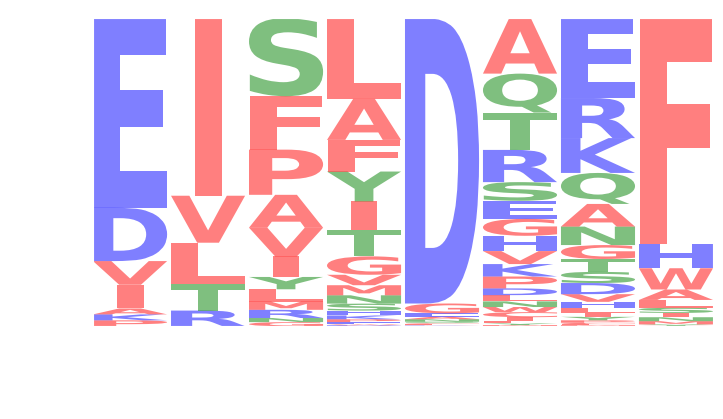

In [8]:
import matplotlib.pyplot as plt
import logomaker
from Bio import SeqIO

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['font.size'] = 18
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

msa_path = "../../data/msa/sadA_full_clean.fasta"
records = list(SeqIO.parse(msa_path, "fasta"))
sequences = [str(r.seq) for r in records]

selected_positions = [38, 48, 71, 152, 157, 172, 233, 261]

AA_COLOR_SCHEME = {
    'G': 'red', 'A': 'red', 'V': 'red', 'C': 'red', 'P': 'red',
    'L': 'red', 'I': 'red', 'M': 'red', 'W': 'red', 'F': 'red',
    'S': 'green', 'T': 'green', 'Y': 'green', 'N': 'green', 'Q': 'green',
    'K': 'blue', 'R': 'blue', 'H': 'blue', 'D': 'blue', 'E': 'blue',
}

output_df = logomaker.alignment_to_matrix(sequences, to_type="counts", characters_to_ignore='-')
output_df = output_df.div(output_df.sum(axis=1), axis=0)
output_df = output_df.iloc[[p - 1 for p in selected_positions], :]
x_labels = [str(p) for p in selected_positions]
output_df = output_df.reset_index(drop=True)

logo = logomaker.Logo(
    output_df,
    figsize=(8, 4),
    color_scheme=AA_COLOR_SCHEME,
    shade_below=0.5,
    fade_below=0.5,
)

logo.ax.set_xticks(range(len(x_labels)))
logo.ax.set_xticklabels(x_labels, rotation=45, ha='right')
logo.ax.set_ylabel("Frequency per Position")
logo.ax.set_xlabel("Position")
logo.ax.set_ylim(0, 1.0)
logo.ax.set_yticks([0, 0.25, 0.50, 0.75, 1.00])

for patch in logo.ax.patches:
    patch.set_alpha(0.5)

# logo.fig.savefig(figs_dir / "msa_logo_promoted_positions.png", dpi=300, bbox_inches='tight', facecolor='white')
# logo.fig.savefig(figs_dir / "msa_logo_promoted_positions.svg", bbox_inches='tight', facecolor='white')
plt.show()

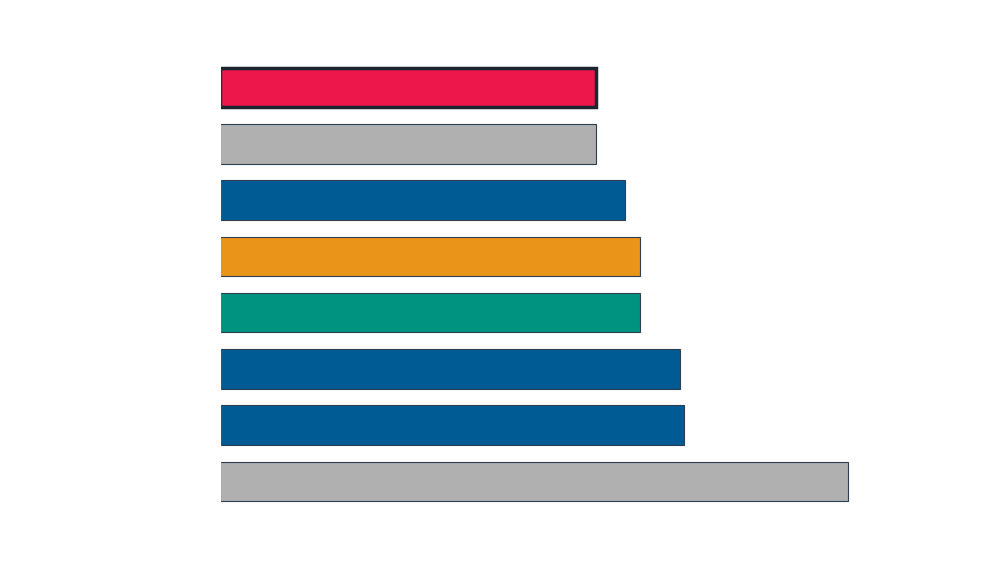

In [10]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'font.size': 12,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

models = [
    {"label": "MLP",                               "mae": 0.5176, "selected": True},
    {"label": "Always Low",                         "mae": 0.5176, "selected": False},
    {"label": "MLP\n(+ DCA)",                       "mae": 0.5578, "selected": False},
    {"label": "Linear",                             "mae": 0.5779, "selected": False},
    {"label": "Linear with\nRegularizer",           "mae": 0.5779, "selected": False},
    {"label": "MLP\n(+ DCA, no library bias)",      "mae": 0.6332, "selected": False},
    {"label": "MLP\n(no library bias, no DCA)",     "mae": 0.6382, "selected": False},
    {"label": "Always Dead",                        "mae": 0.8643, "selected": False},
]

models.sort(key=lambda x: x["mae"])
labels = [m["label"] for m in models]
values = [m["mae"] for m in models]
selected = [m["selected"] for m in models]

def get_color(label):
    if "Always" in label:
        return "#b0b0b0"
    elif label == "MLP":
        return "#ED174C"
    elif "MLP" in label:
        return "#005B94"
    elif "Regularizer" in label:
        return "#009480"
    elif "Linear" in label:
        return "#EA941A"
    return "#b0b0b0"

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(range(len(labels)), values, color=[get_color(l) for l in labels],
               edgecolor="#2C3E50", linewidth=0.8, height=0.7)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=14)
ax.set_xlabel("Mean Absolute Error", fontsize=16)
ax.set_title("Test Set Mean Absolute Error (lower is better)",
             fontsize=16, fontweight="bold", pad=15)
ax.tick_params(axis='x', labelsize=12)
ax.invert_yaxis()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for i, sel in enumerate(selected):
    if sel:
        bars[i].set_linewidth(2.5)
        bars[i].set_edgecolor("#1A252F")

max_val = max(values)
ax.set_xlim(0, max_val * 1.2)
for i, (bar, val) in enumerate(zip(bars, values)):
    text = f"{val:.4f}"
    if selected[i]:
        text += "  (selected)"
    ax.text(bar.get_width() + max_val * 0.015,
            bar.get_y() + bar.get_height() / 2,
            text, va="center", fontsize=12,
            fontweight="bold" if selected[i] else "normal")

plt.tight_layout()
# plt.savefig(figs_dir / "mae_comparison.png", dpi=300, bbox_inches='tight', facecolor='white')
# plt.savefig(figs_dir / "mae_comparison.svg", bbox_inches='tight', facecolor='white')
plt.show()